In [232]:
%pip install numpy pandas optuna scikit-learn kagglehub matplotlib seaborn catboost wandb python-dotenv nbformat


Note: you may need to restart the kernel to use updated packages.


In [233]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from sklearn.metrics import classification_report, accuracy_score
from dotenv import load_dotenv
import os
load_dotenv()

True

In [234]:
RANDOM_SEED = 42
CV_FOLDS = 5

In [235]:
df = pd.read_csv('data/train.csv')

In [236]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [237]:
df.shape

(8693, 14)

In [238]:
df.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [239]:
df['p_group'] = df['PassengerId'].str[:4].astype(int)
df['p_group_id'] = df['PassengerId'].str[5:].astype(int)

In [240]:
groups_and_size = df.groupby('p_group').agg(
    g_size=('p_group', 'count')
)

df = pd.merge(groups_and_size, df, on='p_group', how='inner')

df = df.drop('PassengerId', axis=1)

In [241]:
df['Transported'] = df['Transported'].astype(int)

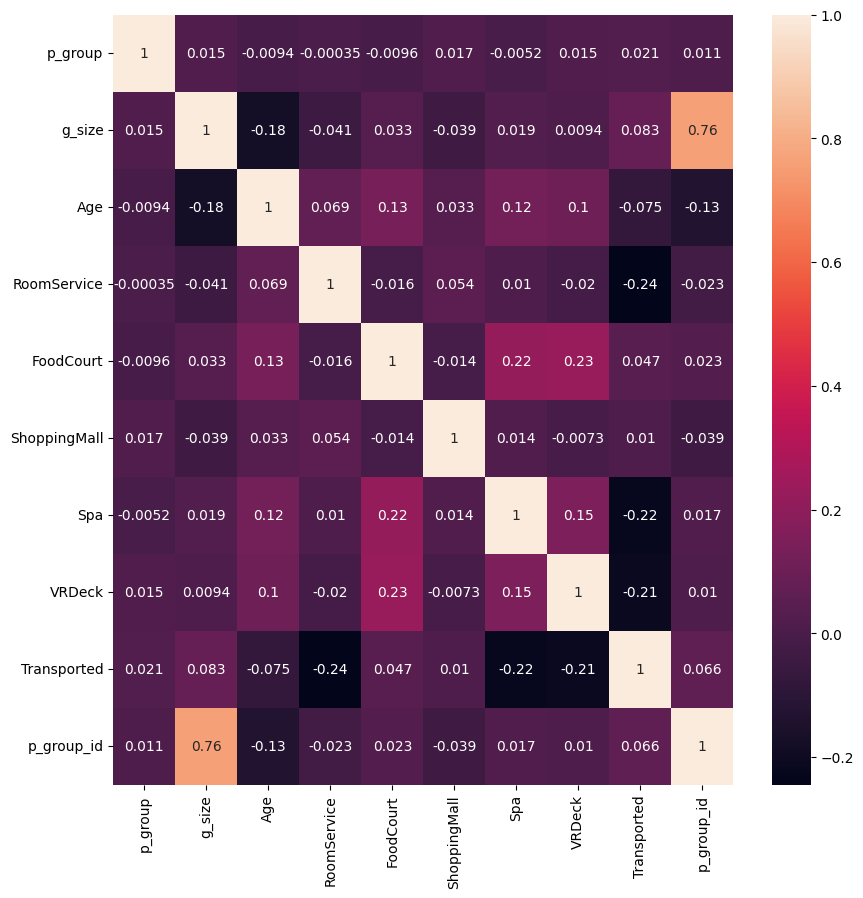

In [242]:
plt.figure(figsize=(10,10))
sns.heatmap(df.select_dtypes('number').corr(), annot=True)
plt.show()

In [243]:
df

,p_group,g_size,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,p_group_id
0,1,1,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0,1
1,2,1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1,1
2,3,2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0,1
3,3,2,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0,2
4,4,1,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276,1,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,0,1
8689,9278,1,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,0,1
8690,9279,1,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,1,1
8691,9280,2,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,0,1


In [244]:
df = df.drop('Name', axis=1)

In [245]:
df.isna().sum()

p_group           0
g_size            0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
p_group_id        0
dtype: int64

In [246]:
# all NaN CryoSleep and spendings cols are 0 -> CryoSleep is True
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

mask = df['CryoSleep'].isna() & (df[spending_cols].sum(axis=1) == 0) & df[spending_cols].notna().all(axis=1)
df.loc[mask, 'CryoSleep'] = True

In [247]:
# CryoSleep is False if any spending exist
mask = df['CryoSleep'].isna() & (df[spending_cols].sum(axis=1) > 0)
df.loc[mask, 'CryoSleep'] = False

In [248]:
# 0 spending where CryoSleep is True

for col in spending_cols:
    mask = (df['CryoSleep'] == True) & df[col].isna()
    df.loc[mask, col] = 0


In [249]:
# HomePlanet, Destination, Cabin (deck/side) — mode of the group
for col in ['HomePlanet', 'Destination']:
    df[col] = df.groupby('p_group')[col].transform(
        lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
    )

In [250]:
still_mistting = df.isna().sum()[df.isna().sum() > 0].keys()
for col in still_mistting:
    df[f'{col}_was_missing'] = df[col].isna().astype(int)


In [251]:
df

,p_group,g_size,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,...,CryoSleep_was_missing,Cabin_was_missing,Destination_was_missing,Age_was_missing,VIP_was_missing,RoomService_was_missing,FoodCourt_was_missing,ShoppingMall_was_missing,Spa_was_missing,VRDeck_was_missing
0,1,1,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,...,0,0,0,0,0,0,0,0,0,0
2,3,2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,...,0,0,0,0,0,0,0,0,0,0
3,3,2,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,...,0,0,0,0,0,0,0,0,0,0
4,4,1,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276,1,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,...,0,0,0,0,0,0,0,0,0,0
8689,9278,1,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
8690,9279,1,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
8691,9280,2,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,...,0,0,0,0,0,0,0,0,0,0


# Baseline Model

In [252]:
df['VIP'] = df['VIP'].astype(float)
df['CryoSleep'] = df['CryoSleep'].astype(float)

In [253]:
df['HomePlanet'] = df['HomePlanet'].astype('object').fillna('missing')
df['Cabin'] = df['Cabin'].astype('object').fillna('missing')
df['Destination'] = df['Destination'].astype('object').fillna('missing')

In [254]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split


X = df.drop('Transported', axis=1)
y = df['Transported']


In [255]:
df.iloc[7]

p_group                               6
g_size                                2
HomePlanet                        Earth
CryoSleep                           1.0
Cabin                             G/0/S
Destination                 TRAPPIST-1e
Age                                28.0
VIP                                 0.0
RoomService                         0.0
FoodCourt                           0.0
ShoppingMall                        0.0
Spa                                 0.0
VRDeck                              0.0
Transported                           1
p_group_id                            2
HomePlanet_was_missing                0
CryoSleep_was_missing                 0
Cabin_was_missing                     0
Destination_was_missing               0
Age_was_missing                       0
VIP_was_missing                       0
RoomService_was_missing               0
FoodCourt_was_missing                 0
ShoppingMall_was_missing              0
Spa_was_missing                       0


In [256]:
import wandb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

cat_features = ['HomePlanet', 'Cabin', 'Destination']

wandb.init(
    project="spaceship-titanic",
    config={
        "model": "catboost",
        "iterations": 3000,
        "learning_rate": 0.01,
        "depth": 5,
        "cv_folds": CV_FOLDS
    }
)

config = wandb.config

kf = StratifiedKFold(n_splits=config.cv_folds, shuffle=True, random_state=RANDOM_SEED)

scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=config.iterations,
        learning_rate=config.learning_rate,
        depth=config.depth,
        cat_features=cat_features,
        verbose=0
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)

    scores.append(acc)

wandb.log({
    "cv_mean": np.mean(scores),
    "cv_std": np.std(scores)
})

wandb.finish()

cv_mean,▁
cv_std,▁
cv_mean,0.79823
cv_std,0.00646


# Submission

🔥 3. Самый правильный вариант (pro level)
Использовать:
Pipeline
ColumnTransformer
или вообще:
👉 отдельный feature.py


🧠 4. Как делают в Kaggle реально сильные участники
Обычно структура такая:
project/
│
├── features.py   ← ВСЕ фичи здесь
├── train.py
├── predict.py


In [257]:
from features import preprocess
preprocess()

1
